# Model Training and Evaluation — Solution

**Dataset:** Car fuel consumption in litres per 100 km.

Run from top to bottom. The steps match the exercise; short answers explain the results.

## Libraries and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

## 1. Compute an error measure

Observed values are 6 and 10; predictions are 5 and 7. Replace the gap with `np.mean(errors ** 2)`. What are the units of RMSE?

In [2]:
observed = np.array([6, 10])
predicted = np.array([5, 7])
errors = observed - predicted
mse = np.mean(errors ** 2)
print('MSE:', mse, 'RMSE:', np.sqrt(mse))

MSE: 5.0 RMSE: 2.23606797749979


**Answer:** MSE = 5 and RMSE ≈ 2.24 L/100 km.

- The errors are 6 − 5 = 1 and 10 − 7 = 3.
- The squared errors are 1 and 9; their mean is (1 + 9) / 2 = 5. This is the MSE, in (L/100 km)².
- The square root of 5 is about 2.24. Taking the root brings the error back to the units of the target, so RMSE is in L/100 km.

## 2. Load and split the data

Preparation is provided. Which variables are inputs? Why do we reserve test rows?

In [3]:
cars = pd.read_csv('../00_Data/car_fuel_consumption_2025.csv')
cars = cars.dropna(subset=['engine_size', 'cylinders', 'combined'])
print(cars[['engine_size', 'cylinders', 'combined']].head())
X = cars[['engine_size', 'cylinders']]
y = cars['combined']  # litres per 100 km
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Training rows:', len(X_train), 'Test rows:', len(X_test))

   engine_size  cylinders  combined
0          1.5          4       8.5
1          1.5          4       7.4
2          1.5          4       7.8
3          2.0          4       9.9
4          3.5          6      11.2
Training rows: 560 Test rows: 141


**Answer:** Engine size and number of cylinders are the inputs; combined consumption (L/100 km) is the target.

- The 701 cars are split into 560 training rows (80%) and 141 test rows (20%).
- The model is fitted on the 560 training cars only.
- The 141 test cars play the role of new cars: they show how well the model predicts cars it has never seen.

## 3. Train a first model

Replace the gap with `LinearRegression()`. Are predictions identical to observed values?

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print(pd.DataFrame({'Observed': y_test, 'Predicted': prediction}).head().round(2))
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, prediction)))

     Observed  Predicted
680      11.7      11.59
164      10.6      11.23
54       11.4      11.23
640       4.7       8.87
606      15.9      11.23
Test RMSE: 1.8529471152459156


**Answer:** No, the predictions differ from the observed values, sometimes by a lot.

- The fitted rule is: consumption = 4.69 + 0.905 · engine size + 0.637 · cylinders.
- Car 680 (Toyota Tundra Hybrid) is predicted well: observed 11.7, predicted 11.59.
- Car 640 (Toyota Corolla Hybrid) uses only 4.7 L/100 km but is predicted at 8.87. The hybrid drive lowers consumption, but the model does not know about it.
- Car 606 (Ram 1500 pickup) uses 15.9 but is predicted at 11.23. Its heavy body is not among the inputs either.
- On all 141 test cars, the test RMSE is 1.85 L/100 km. For comparison, predicting the training mean (10.87) for every car would give a test RMSE of 2.91. The two inputs therefore reduce the typical error by about one litre per 100 km.

## 4. Cross-validation

CV code is provided. Scikit-learn returns negative MSE because its score convention is “larger is better”; the minus sign converts it back. Why are test rows excluded?

In [5]:
scores = cross_val_score(LinearRegression(), X_train, y_train,
                         cv=5, scoring='neg_mean_squared_error')
fold_rmse = np.sqrt(-scores)
print('Fold RMSE:', fold_rmse.round(2))
print('Mean CV RMSE:', fold_rmse.mean().round(2))

Fold RMSE: [1.89 1.56 1.63 1.73 1.83]
Mean CV RMSE: 1.73


**Answer:** CV estimates the prediction error using training rows only, so the test rows stay untouched for the final check.

- The five folds give RMSE values between 1.56 and 1.89 L/100 km; their mean is 1.73.
- The spread between folds shows that one split alone gives a somewhat random answer. The mean of five folds is more stable.
- The single test RMSE from step 3 (1.85) lies within this range.
- If we used the test rows to compare or tune models, the test error would no longer be an honest estimate for new cars.

## 5. Compare model complexity

Run the supplied comparison. Which depth has the smallest CV error? Does smallest training error identify the best model? This is a demonstration; the earlier linear model remains our fixed test example.

   Depth  Training RMSE  CV RMSE
0      1           1.94     1.94
1      3           1.58     1.65
2     15           1.43     1.56


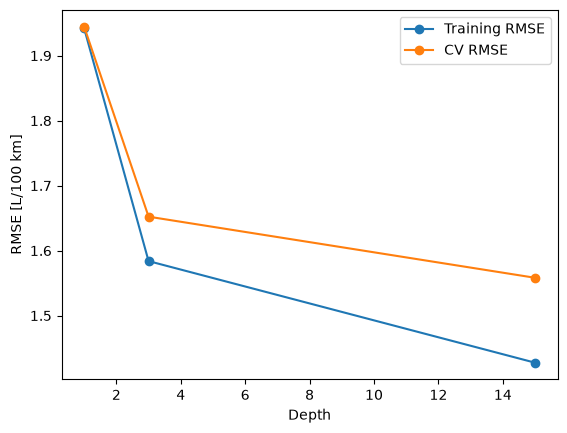

In [6]:
rows = []
for depth in [1, 3, 15]:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, tree.predict(X_train)))
    scores = cross_val_score(tree, X_train, y_train, cv=5,
                             scoring='neg_mean_squared_error')
    rows.append([depth, train_rmse, np.sqrt(-scores).mean()])
results = pd.DataFrame(rows, columns=['Depth', 'Training RMSE', 'CV RMSE'])
print(results.round(2))
results.plot(x='Depth', y=['Training RMSE', 'CV RMSE'], marker='o')
plt.ylabel('RMSE [L/100 km]')
plt.show()

**Answer:** Depth 15 has the smallest CV RMSE: 1.56 L/100 km, compared with 1.65 for depth 3 and 1.94 for depth 1.

- Depth 1 has the same training and CV RMSE (1.94): one split is too simple, so it underfits.
- From depth 1 to depth 15, the training RMSE falls from 1.94 to 1.43.
- The gap between training and CV RMSE grows from 0.00 at depth 1 to 0.13 at depth 15. A deeper tree adapts more to the training rows.
- The smallest training RMSE alone does not identify the best model: training error usually keeps falling as the tree gets deeper, because a deep tree can memorise training details. Only the CV error shows how well each tree predicts rows it did not see.
- Here the CV error still falls with depth, so with only two inputs, depth 15 is not yet clearly overfitting.

### Jupyter notebook — footer info

Include this information when submitting your notebook.

In [7]:
import platform
from datetime import datetime
print(platform.platform())
print("Python:", platform.python_version())
print("Date:", datetime.now().isoformat(timespec="seconds"))

Linux-6.8.0-1064-azure-x86_64-with-glibc2.41
Python: 3.11.16
Date: 2026-10-02T20:16:51
